# **HMS VS WED WITH XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2500 - loss: 0.8200 - precision_1: 0.3333 - recall_1: 0.2000 - val_accuracy: 0.6667 - val_loss: 64.6446 - val_precision_1: 0.6667 - val_recall_1: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6250 - loss: 43.0854 - precision_1: 0.6250 - recall_1: 1.0000 - val_accuracy: 0.3333 - val_loss: 41.7849 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 1.0000 - loss: 2.9920e-05 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 0.3333 - val_loss: 136.0949 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.3750 - loss: 59.4304 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 23.6844 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_1: 

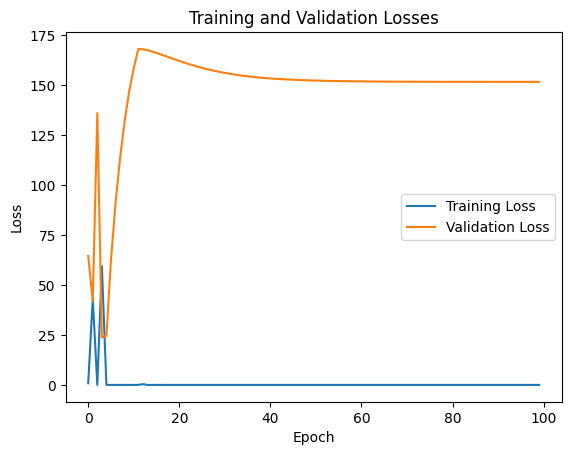

[[0 4]
 [0 2]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         4
         1.0       0.33      1.00      0.50         2

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/HMS VS WED(ch)transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **HMS VS WED WITHOUT XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6250 - loss: 0.6568 - precision_4: 0.7500 - recall_4: 0.6000 - val_accuracy: 0.3333 - val_loss: 108.4890 - val_precision_4: 0.3333 - val_recall_4: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6250 - loss: 30.7973 - precision_4: 0.6250 - recall_4: 1.0000 - val_accuracy: 0.6667 - val_loss: 43.5154 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5000 - loss: 10.8162 - precision_4: 1.0000 - recall_4: 0.2000 - val_accuracy: 0.3333 - val_loss: 14.1544 - val_precision_4: 0.3333 - val_recall_4: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_4: 1.0000 - recall_4: 1.0000 - val_accuracy: 0.3333 - val_loss: 92.2651 - val_precision_4: 0.3333 - val_recall_4: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_4: 1.0000 - recall_4: 1.000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
  Sample_Name  Actual  Predicted
0        DH46     1.0        1.0
1        LJ26     1.0        1.0
2       22531     0.0        1.0
3        YE37     1.0        1.0
4       22517     0.0        1.0


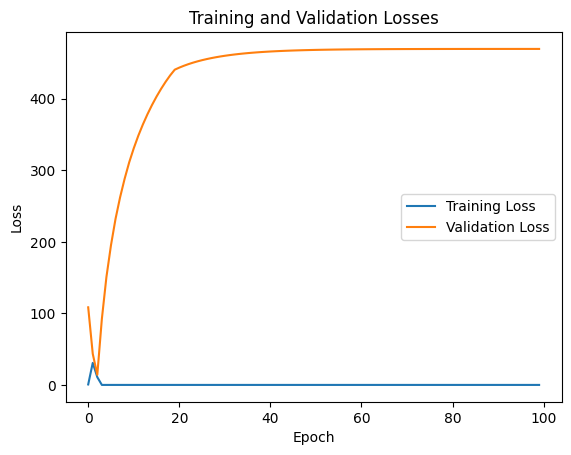

[[0 3]
 [0 3]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/HMS VS WED(wxy)transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **NES VS HMS WITH XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5000 - loss: 0.7042 - precision_5: 0.5714 - recall_5: 0.8000 - val_accuracy: 0.6667 - val_loss: 35.0790 - val_precision_5: 0.6667 - val_recall_5: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6250 - loss: 12.0783 - precision_5: 0.6250 - recall_5: 1.0000 - val_accuracy: 0.3333 - val_loss: 73.3006 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8750 - loss: 0.6115 - precision_5: 1.0000 - recall_5: 0.8000 - val_accuracy: 0.3333 - val_loss: 95.7731 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8750 - loss: 0.1819 - precision_5: 1.0000 - recall_5: 0.8000 - val_accuracy: 0.3333 - val_loss: 65.0454 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_5: 1.0000 - rec

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
  Sample_Name  Actual  Predicted
0        DH46     1.0        1.0
1       3747S     0.0        1.0
2        1838     0.0        1.0
3       3747M     0.0        1.0
4        YG10     1.0        1.0


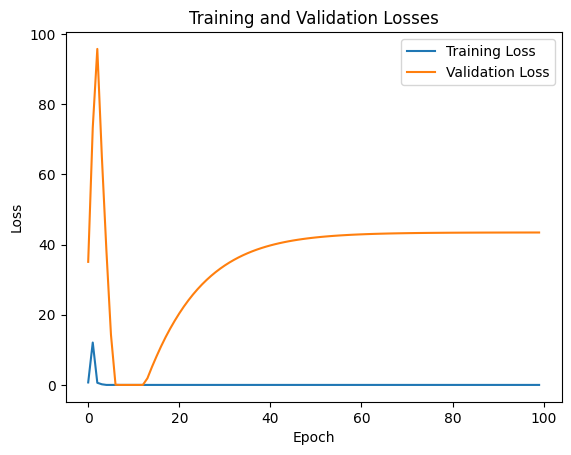

[[0 3]
 [0 2]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES VS HMS(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **NES VS HMS WITHOUT XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.3750 - loss: 0.7324 - precision_6: 0.3333 - recall_6: 0.6667 - val_accuracy: 0.3333 - val_loss: 166.5264 - val_precision_6: 0.0000e+00 - val_recall_6: 0.0000e+00
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6250 - loss: 71.4413 - precision_6: 0.0000e+00 - recall_6: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 28.4586 - val_precision_6: 0.0000e+00 - val_recall_6: 0.0000e+00
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 1.0000 - loss: 2.0526e-09 - precision_6: 1.0000 - recall_6: 1.0000 - val_accuracy: 0.6667 - val_loss: 7.8599 - val_precision_6: 0.6667 - val_recall_6: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 1.0000 - loss: 4.7829e-21 - precision_6: 1.0000 - recall_6: 1.0000 - val_accuracy: 0.6667 - val_loss: 19.0577 - val_precision_6: 0.6667 - val_recall_6: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 1.0000 - loss: 0.0025 - precision_6: 1.0000 -

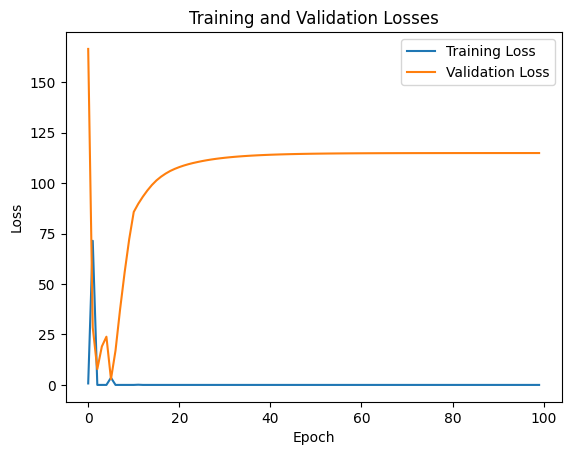

[[1 0]
 [4 0]]
              precision    recall  f1-score   support

         0.0       0.20      1.00      0.33         1
         1.0       0.00      0.00      0.00         4

    accuracy                           0.20         5
   macro avg       0.10      0.50      0.17         5
weighted avg       0.04      0.20      0.07         5



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES VS HMS(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **NES VS WED WITH XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3750 - loss: 0.7144 - precision_8: 0.3333 - recall_8: 0.2500 - val_accuracy: 1.0000 - val_loss: 0.1948 - val_precision_8: 1.0000 - val_recall_8: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss: 3.8354e-26 - precision_8: 1.0000 - recall_8: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1053 - val_precision_8: 1.0000 - val_recall_8: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 1.4013e-42 - precision_8: 1.0000 - recall_8: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0501 - val_precision_8: 1.0000 - val_recall_8: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_8: 1.0000 - recall_8: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0230 - val_precision_8: 1.0000 - val_recall_8: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_8: 1.0000 - recall_8: 1.0000 - val

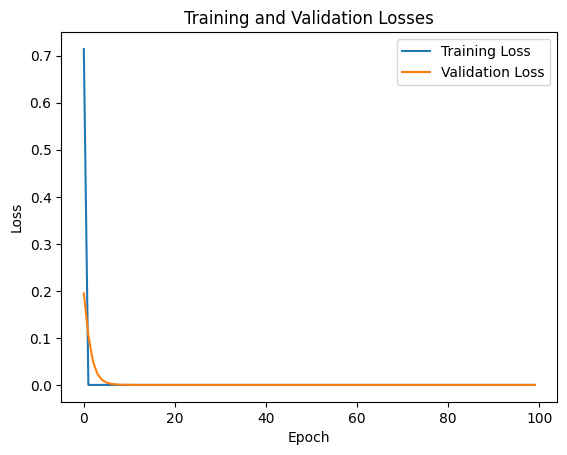

[[2 0]
 [0 3]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_WED(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **NES VS WED WITHOUT XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3750 - loss: 0.7090 - precision_11: 0.0000e+00 - recall_11: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 58.4783 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6250 - loss: 19.4261 - precision_11: 0.0000e+00 - recall_11: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 61.0879 - val_precision_11: 0.5000 - val_recall_11: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3750 - loss: 13.9890 - precision_11: 0.3750 - recall_11: 1.0000 - val_accuracy: 0.5000 - val_loss: 30.3993 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_11: 1.0000 - recall_11: 1.0000 - val_accuracy: 0.5000 - val_loss: 96.5074 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 2.7

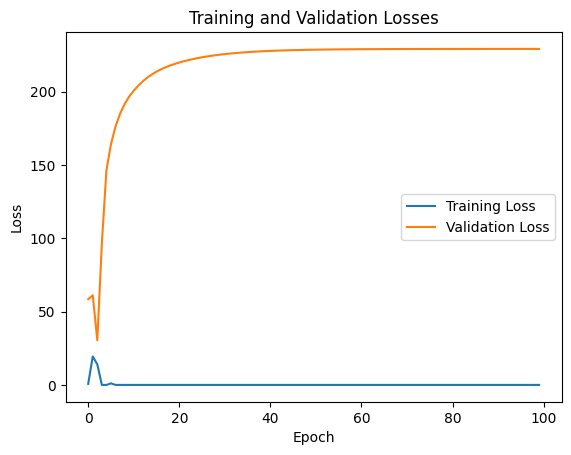

[[1 0]
 [4 0]]
              precision    recall  f1-score   support

         0.0       0.20      1.00      0.33         1
         1.0       0.00      0.00      0.00         4

    accuracy                           0.20         5
   macro avg       0.10      0.50      0.17         5
weighted avg       0.04      0.20      0.07         5



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_WED(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


## #NES VS HMS VS WED WITH XY

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - accuracy: 0.0833 - loss: 1.2702 - val_accuracy: 0.2500 - val_loss: 264.8839
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5000 - loss: 44.8174 - val_accuracy: 0.2500 - val_loss: 466.7072
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5000 - loss: 162.9321 - val_accuracy: 0.2500 - val_loss: 363.6304
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5000 - loss: 65.5886 - val_accuracy: 0.5000 - val_loss: 202.4342
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9167 - loss: 6.7993 - val_accuracy: 0.2500 - val_loss: 286.9772
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9167 - loss: 6.8009 - val_accuracy: 0.2500 - val_loss: 334.2845
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.4167 - loss: 42.3135 - val_accuracy: 0.2500 - val_loss: 285.4252
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6667 - loss: 10.9051 - val_accuracy: 0.2

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


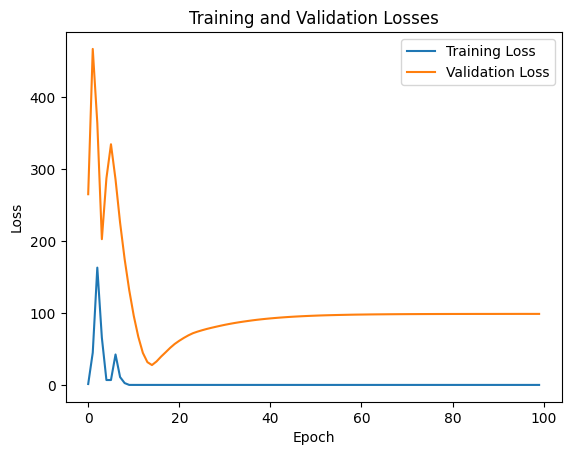

Confusion Matrix:
[[0 4 0]
 [0 1 0]
 [0 3 0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.12      1.00      0.22         1
           2       0.00      0.00      0.00         3

    accuracy                           0.12         8
   macro avg       0.04      0.33      0.07         8
weighted avg       0.02      0.12      0.03         8



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from tensorflow.keras.utils import to_categorical

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_HMS_VS_WED(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('int')  # Convert to integers for classification

# One-hot encode the target variable
Y_categorical = to_categorical(Y, num_classes=3)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Add a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y_categorical, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Dropout layer for regularization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer for 3 classes
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # Convert predictions to class indices
Y_test_classes = np.argmax(Y_test, axis=1)  # Convert one-hot test labels to class indices

# Compute overall precision, recall, and F1-score
precision = precision_score(Y_test_classes, Y_pred_classes, average='weighted')
recall = recall_score(Y_test_classes, Y_pred_classes, average='weighted')
overall_accuracy = accuracy_score(Y_test_classes, Y_pred_classes)

print(f"Overall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall Accuracy: {overall_accuracy}")

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test_classes,
    'Predicted': Y_pred_classes
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions_multiclass.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(Y_test_classes, Y_pred_classes))
print("Classification Report:")
print(classification_report(Y_test_classes, Y_pred_classes))


# **NES VS HMS VS WED WITHOUT XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 1.0638 - val_accuracy: 0.5000 - val_loss: 122.0759
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5833 - loss: 31.3612 - val_accuracy: 0.0000e+00 - val_loss: 251.3050
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3333 - loss: 81.6334 - val_accuracy: 0.5000 - val_loss: 53.9781
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 72.4835
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8333 - loss: 9.4776 - val_accuracy: 0.5000 - val_loss: 55.4979
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9167 - loss: 2.0203 - val_accuracy: 0.5000 - val_loss: 29.5873
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 8.6107
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy:

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


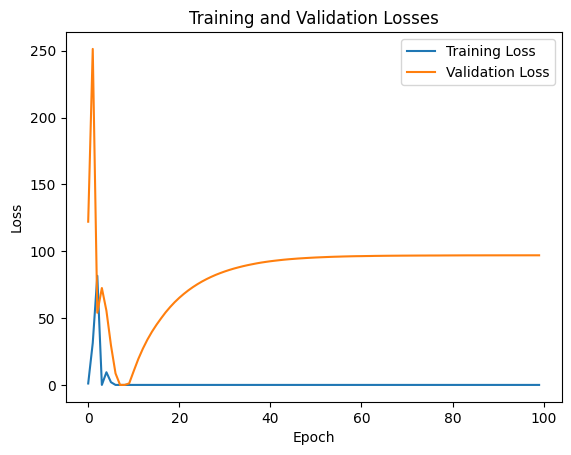

Confusion Matrix:
[[0 3 0]
 [0 0 0]
 [0 5 0]]
Classification Report:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       3.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       5.0

    accuracy                           0.00       8.0
   macro avg       0.00      0.00      0.00       8.0
weighted avg       0.00      0.00      0.00       8.0



In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from tensorflow.keras.utils import to_categorical

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/NES_VS_HMS_VS_WED(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('int')  # Convert to integers for classification

# One-hot encode the target variable
Y_categorical = to_categorical(Y, num_classes=3)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Add a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y_categorical, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Dropout layer for regularization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer for 3 classes
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical crossentropy
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # Convert predictions to class indices
Y_test_classes = np.argmax(Y_test, axis=1)  # Convert one-hot test labels to class indices

# Compute overall precision, recall, and F1-score
precision = precision_score(Y_test_classes, Y_pred_classes, average='weighted')
recall = recall_score(Y_test_classes, Y_pred_classes, average='weighted')
overall_accuracy = accuracy_score(Y_test_classes, Y_pred_classes)

print(f"Overall Precision: {precision}")
print(f"Overall Recall: {recall}")
print(f"Overall Accuracy: {overall_accuracy}")

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test_classes,
    'Predicted': Y_pred_classes
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions_multiclass.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(Y_test_classes, Y_pred_classes))
print("Classification Report:")
print(classification_report(Y_test_classes, Y_pred_classes))


# **SKIN VS MUSCLE TISSUES WITH XY**

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.5222 - precision_12: 1.0000 - recall_12: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_12: 1.0000 - val_recall_12: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_12: 1.0000 - recall_12: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_12: 1.0000 - val_recall_12: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_12: 1.0000 - recall_12: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_12: 1.0000 - val_recall_12: 1.0000
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_12: 1.0000 - recall_12: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision_12: 1.0000 - val_recall_12: 1.0000
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision_

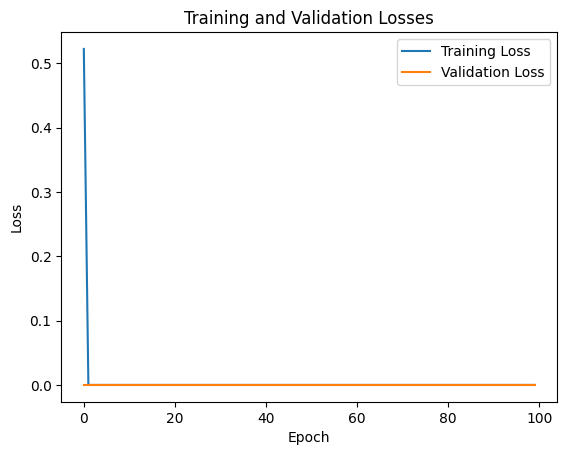

[[0 2]
 [0 1]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         2
         1.0       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/Tissues_VS_Muscle(ch)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))


# **SKIN VS MUSCLE TISSUES WITHOUT XY**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.3333 - loss: 0.8321 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 8.5134e-28 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6667 - loss: 12.7995 - precision: 0.6667 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.4913 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 7.4575e-19 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_loss: 42.3166 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 1.4164e-06 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_loss: 71.3725 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6667 - loss: 2.4195 - precision: 1.0000 - recall: 0.5

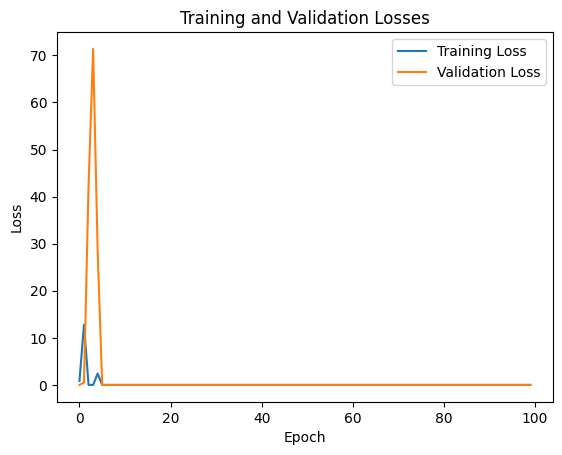

[[0 1]
 [0 2]]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset with low_memory=False to prevent dtype warning
data = pd.read_csv("/content/Tissues_VS_Muscle(wxy)_transposed.csv", header=0, low_memory=False)

# Check if 'Classification' is correctly named
target_column = 'Classification'
if target_column not in data.columns:
    print(f"Column '{target_column}' not found. Available columns: {data.columns}")

# Set 'Position' column as the index for easy reference
data.set_index('Position', inplace=True)

# Extract features and target variable
X = data.drop(columns=[target_column]).values.astype('float32')
Y = data[target_column].values.astype('float32')

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape input data for CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)  # Adding a channel dimension

# Store indices before splitting
indices = data.index

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test, train_indices, test_indices = train_test_split(
    X_reshaped, Y, indices, test_size=0.3, shuffle=True
)

# Define CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),  # Added dropout layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Train model
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate model
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# Predict on the test set
Y_pred = model.predict(X_test)
Y_pred_classes = (Y_pred > 0.5).astype('float32')

# Prepare results DataFrame
results = pd.DataFrame({
    'Sample_Name': test_indices,
    'Actual': Y_test,
    'Predicted': Y_pred_classes.flatten()
})

# Save results to CSV if needed
results.to_csv('/content/model_predictions.csv', index=False)

# Print the results DataFrame
print(results.head())

# Plot training and validation losses
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Confusion matrix and classification report
print(confusion_matrix(Y_test, Y_pred_classes))
print(classification_report(Y_test, Y_pred_classes))
